# Compare HST: Direct pRT vs Pipeline

Wavelength range: 0.98 – 2.2 μm

In [1]:
import os
os.environ['pRT_input_data_path'] = '/media/mvasist/Elements/PhDprojects/scratch/input_data_v2.4.9/input_data'

import sys
sys.path.insert(0, '/home/mvasist/Documents/SBI4atmret')
sys.path.insert(0, '/home/mvasist/Documents/WISEJ1738/sbi_ear')

import numpy as np
import torch
import yaml
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

from petitRADTRANS import nat_cst as nc, Radtrans
import petitRADTRANS as prt

from sbi4atmret.config.configs import BaseConfig
from sbi4atmret.datasets.theta_mapper.thetamapperbase import BaseThetaMapper


sys.path.insert(0, '/home/mvasist/Documents/WISEJ1738/sbi_ear')
from code2explore.observations import load_observations

obs_wlen_miri, obs_miri, sigmaM, \
    obs_wlen_gemini, obs_gemini, sigmaG, \
    obs_wlen_hst, obs_hst, sigmaH, \
    wlength_gm, wlength_hm, \
    x_star_g, x_star_h = load_observations()

print(f"MIRI: {len(obs_wlen_miri)} points")
print(f"HST: {len(obs_wlen_hst)} points")
print(f"Gemini: {len(obs_wlen_gemini)} points")


MIRI: 1298 points
HST: 129 points
Gemini: 305 points


## 1. Load config + build pipeline simulator

In [2]:
config_path = '/home/mvasist/Documents/SBI4atmret/experiments/config_MiriGeminiHST_cloudfree.yaml'
with open(config_path) as f:
    config = BaseConfig(**yaml.safe_load(f))

simulators = config.build_simulators()
prior = config.build_prior()

sim_name = 'cloudfree_hst'
simulator = simulators[sim_name]
print(f"Pipeline simulator: {sim_name}")
print(f"  wavelength range: [{simulator.a}, {simulator.b}] μm")
print(f"  params ({len(simulator.names)}): {simulator.names}")
print(f"  scale: {simulator.scale}")

Pipeline simulator: cloudfree_hst
  wavelength range: [0.98, 2.2] μm
  params (26): ['R_pl', 'mass', 'T_bottom', 'temp_node_1', 'temp_node_2', 'temp_node_3', 'temp_node_4', 'temp_node_5', 'temp_node_6', 'temp_node_7', 'temp_node_8', 'temp_node_9', 'H2O_mol_scale', 'CO2_mol_scale', 'CO_mol_scale', 'CH4_mol_scale', 'NH3_mol_scale', 'PH3_mol_scale', 'H2S_mol_scale', '15NH3_mol_scale', 'HCN_mol_scale', 'TiO_mol_scale', 'VO_mol_scale', 'mixture_fraction', 'Cushing_scale_factor_h', 'bfactor_noise_hst']
  scale: 100000.0


## 2. Build theta mapper + sample

In [3]:
class _MinimalDomain:
    def __init__(self, simulator_dict):
        self.simulator_dict = simulator_dict

theta_mapper = BaseThetaMapper(
    domain=_MinimalDomain(simulators),
    posterior_param_names=config.get_parameter_names(),
)

theta_merged = prior.sample((1,))
theta_dict = theta_mapper.split_theta(theta_merged)

theta_hst = theta_dict[sim_name][0].numpy()
print(f"HST theta ({len(theta_hst)} params): {theta_hst}")

HST theta (26 params): [ 8.0965972e-01  4.4013042e+01  5.4656769e+02  2.2008406e-01
  8.1394851e-01  4.0535051e-01  2.8579229e-01  4.8901236e-01
  3.4381455e-01  6.1479992e-01  4.9504423e-01  7.8810501e-01
 -9.7953587e+00 -4.9118385e+00 -7.7630234e-01 -9.1444645e+00
 -4.6951346e+00 -8.3751078e+00 -5.0785980e+00 -1.6880407e+00
 -6.9332561e+00 -9.5983515e+00 -7.5598545e+00  0.0000000e+00
  0.0000000e+00 -1.2629581e+01]


## 3. Run Pipeline Simulator

In [4]:
output_pipeline = simulator(theta_hst)

if output_pipeline.spectrum is not None:
    print(f"Pipeline SUCCESS")
    print(f"  spectrum: {output_pipeline.spectrum.shape}")
    print(f"  wavelength: [{output_pipeline.wavelength.min():.2f}, {output_pipeline.wavelength.max():.2f}] μm")
    print(f"  flux range: [{output_pipeline.spectrum.min():.2e}, {output_pipeline.spectrum.max():.2e}]")
else:
    print("Pipeline FAILED")

Pipeline SUCCESS
  spectrum: (809,)
  wavelength: [0.98, 2.20] μm
  flux range: [5.90e-51, 1.02e-06]


## 4. Run Old WISEJ1738 Simulator

In [5]:
from ees_MIRIinsts import Simulator as OldSimulator

old_sim = OldSimulator(a=0.98, b=2.2, noisy=False)
spectrum_old = old_sim(theta_hst)

wlen_old = old_sim.wavelength
print(f"Old simulator: {spectrum_old.shape} points")
print(f"  wavelength: [{wlen_old.min():.2f}, {wlen_old.max():.2f}] μm")
print(f"  flux range: [{(spectrum_old * old_sim.scale).min():.2e}, {(spectrum_old * old_sim.scale).max():.2e}]")

Old simulator: (809,) points
  wavelength: [0.98, 2.20] μm
  flux range: [6.71e-46, 1.25e-01]


## 5. Compare

Same grid: (809,) == (809,)
Max |residual|: 2.24e-07
Mean |residual|: 1.23e-08


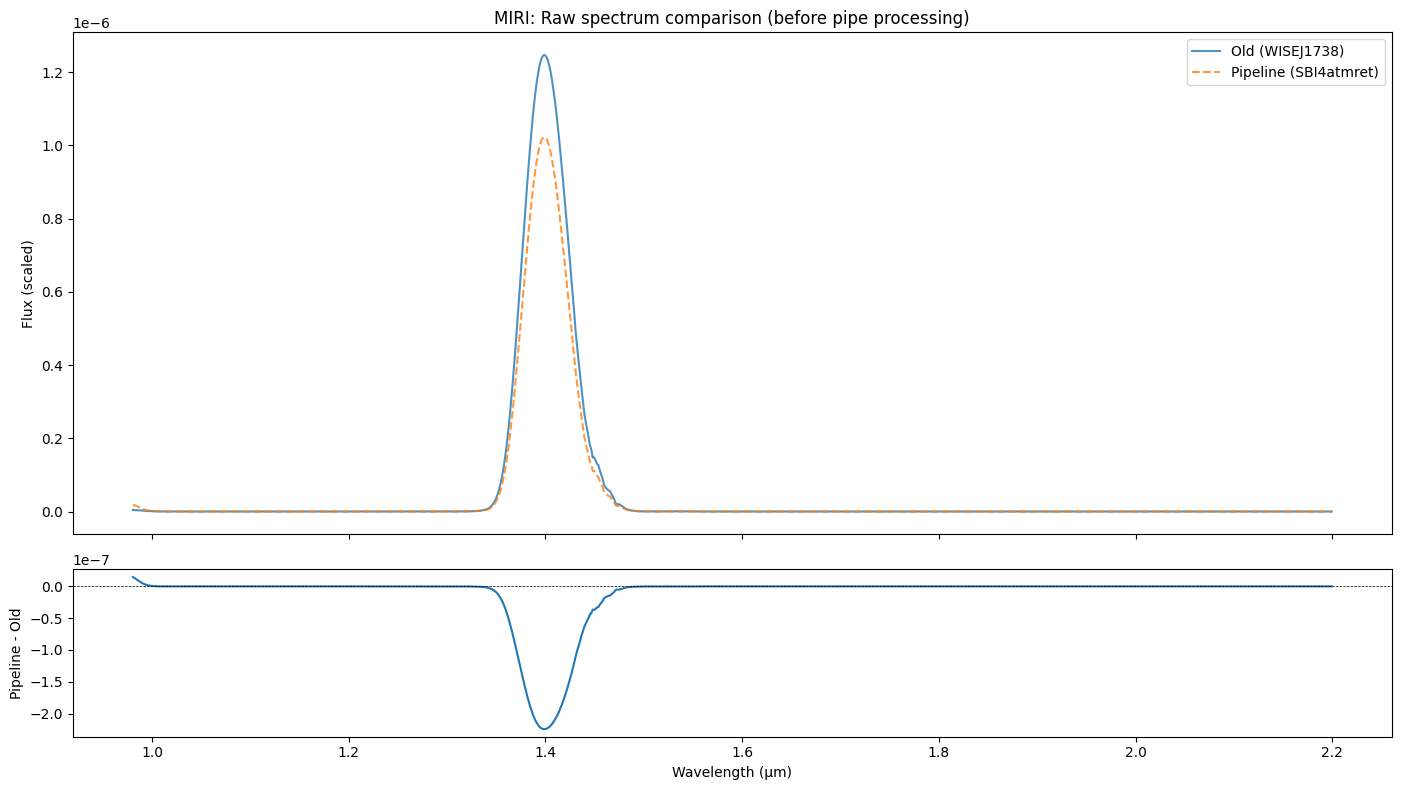

In [6]:
# Residual — direct comparison (same wavelength grid, apply pipe trimming)
if output_pipeline.spectrum is not None:
    # Old simulator produces the full spectrum on the same pRT wavelength grid
    # The pipe trims MIRI to indices 1:1299
    spectrum_old_scaled = spectrum_old 
    spectrum_old_trimmed = spectrum_old_scaled # same as pipe.modify_spec for MIRI
    
    # Pipeline output should already be trimmed (from _compute_emission → process)
    # But pipeline returns the FULL raw spectrum (before pipe processing)
    # So compare raw-to-raw first:
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                    gridspec_kw={'height_ratios': [3, 1]})
    
    # Full raw spectra (before pipe trimming)
    ax1.plot(wlen_old, spectrum_old_scaled, label='Old (WISEJ1738)', alpha=0.8)
    ax1.plot(output_pipeline.wavelength, output_pipeline.spectrum,
             label='Pipeline (SBI4atmret)', alpha=0.8, linestyle='--')
    ax1.set_ylabel('Flux (scaled)')
    ax1.legend()
    ax1.set_title('MIRI: Raw spectrum comparison (before pipe processing)')
    
    # Direct residual on same grid (no interpolation)
    # Both should have the same wavelength grid from pRT
    if output_pipeline.wavelength.shape == wlen_old.shape:
        residual = output_pipeline.spectrum - spectrum_old_scaled
        ax2.plot(output_pipeline.wavelength, residual)
        ax2.axhline(0, color='k', linestyle='--', linewidth=0.5)
        ax2.set_ylabel('Pipeline - Old')
        ax2.set_xlabel('Wavelength (μm)')
        print(f"Same grid: {output_pipeline.wavelength.shape} == {wlen_old.shape}")
        print(f"Max |residual|: {np.max(np.abs(residual)):.2e}")
        print(f"Mean |residual|: {np.mean(np.abs(residual)):.2e}")
    else:
        print(f"DIFFERENT grid sizes: pipeline={output_pipeline.wavelength.shape}, old={wlen_old.shape}")
        print("  This means the emission models produce different grid sizes.")
        print(f"  Pipeline: [{output_pipeline.wavelength.min():.4f}, {output_pipeline.wavelength.max():.4f}]")
        print(f"  Old:      [{wlen_old.min():.4f}, {wlen_old.max():.4f}]")
    
    plt.tight_layout()
    plt.show()


Pipeline processed shapes:
  HST:    (129,)
HST — Max |residual|: 1.76e-14


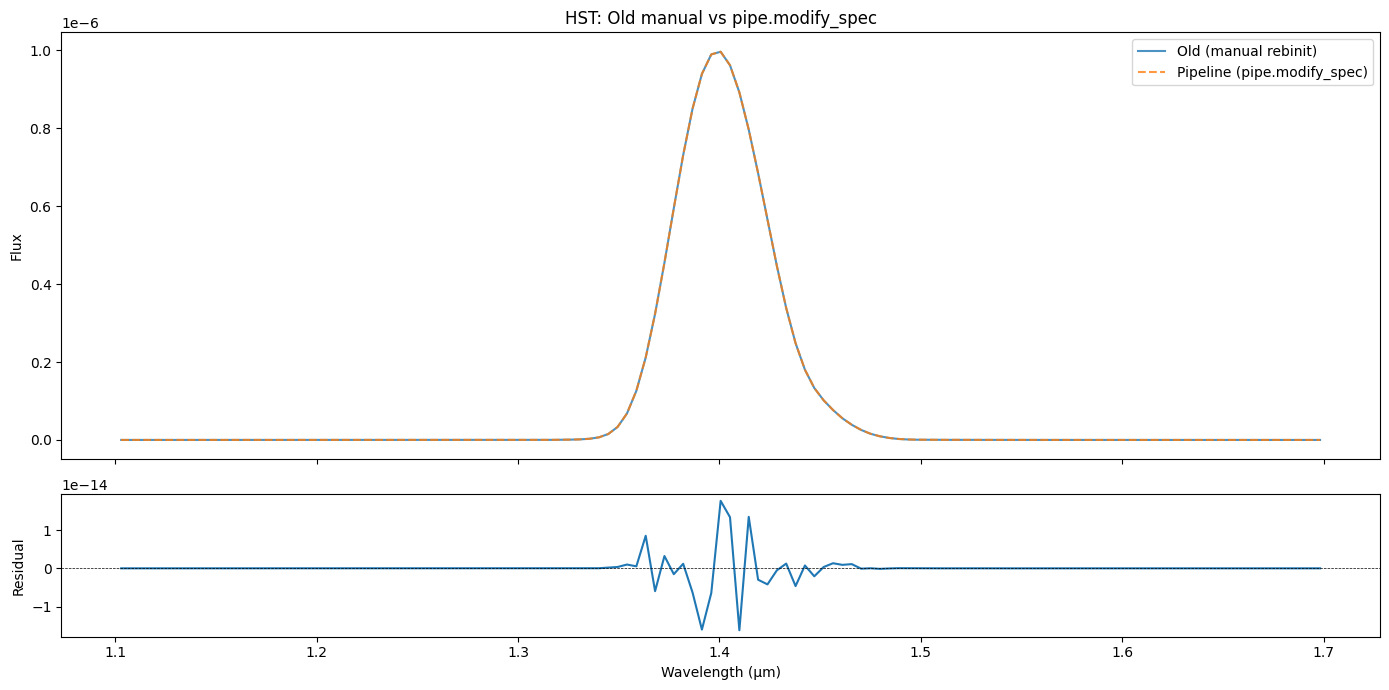

In [ ]:
# ============================================================
# 6. Compare AFTER pipe processing — use pipe.modify_spec
# ============================================================

from petitRADTRANS.retrieval.rebin_give_width import rebin_give_width
from petitRADTRANS.retrieval.data import Data

# --- Pipeline: use the actual pipe class ---
# Build a batch_dict with all simulators' outputs (pipe expects all 3)
# We need outputs from all simulators for the same theta

# Run all simulators with the same merged theta
theta_dict_all = theta_mapper.split_theta(theta_merged)

outputs_all = {}
for sn, sim in simulators.items():
    th = theta_dict_all[sn][0].numpy()
    out = sim(th)
    outputs_all[sn] = out

# Build batch_dict in pipe format: {sim_name: (theta_tensor, x_tensor)}
batch_dict = {}
for sn in simulators.keys():
    th_tensor = theta_dict_all[sn]  # (1, D_inst)
    x_tensor = torch.from_numpy(outputs_all[sn].spectrum).float().unsqueeze(0)  # (1, D_spec)
    batch_dict[sn] = (th_tensor, x_tensor)

# Apply pipe.modify_spec (does trimming for MIRI, masking for Gemini, rebinning for HST)
from sbi4atmret.datasets.pipes.pipe_cloudfree_MiriGeminiHST import MiriGeminiHSTcloudfreePipe

# Skip pipe constructor — just call modify_spec on a manually-built pipe
pipe = MiriGeminiHSTcloudfreePipe.__new__(MiriGeminiHSTcloudfreePipe)

# Set the mask and obs wavelengths the pipe needs
pipe._mask = torch.zeros(len(simulators['cloudfree_hst'].wavelength), dtype=torch.bool)
for ind in range(len(obs_wlen_gemini)):
    pipe._mask = pipe._mask | torch.isin(
        torch.from_numpy(simulators['cloudfree_hst'].wavelength),
        torch.tensor(obs_wlen_gemini[ind])
    )

# Need domain for _rebinit
class _FakeDomain:
    def __init__(self):
        self.sim_wlens = {
            "cloudfree_hst": simulators['cloudfree_hst'].wavelength
        }
        self.obs_wlens = {
            "hst": obs_wlen_hst
        }
pipe.domain = _FakeDomain()

# Apply modify_spec
processed = pipe.modify_spec(batch_dict)

# Extract processed spectra

x_hst_pipe = processed['cloudfree_hst'][1][0].numpy()     # (D_hst_rebinned,)

print(f"Pipeline processed shapes:")
print(f"  HST:    {x_hst_pipe.shape}")

# --- Old code: apply same processing manually ---
def rebinit_old(spectrum, wlen_sim, obs_wlen, indx_start=115, indx_end=552, R=130):
    spectrum_trimmed = spectrum[indx_start:indx_end]
    wlen_trimmed = wlen_sim[indx_start:indx_end]
    wlen_bins = np.zeros_like(obs_wlen)
    wlen_bins[:-1] = np.diff(obs_wlen)
    wlen_bins[-1] = wlen_bins[-2]
    convolved = Data.convolve(wlen_trimmed, spectrum_trimmed, R)
    rebinned = rebin_give_width(wlen_trimmed, convolved, obs_wlen, wlen_bins)
    return rebinned


old_hst_raw = outputs_all['cloudfree_hst'].spectrum 

x_hst_old = rebinit_old(old_hst_raw, simulators['cloudfree_hst'].wavelength, obs_wlen_hst)

# --- Plot comparison for HST ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(obs_wlen_hst, x_hst_old, label='Old (manual rebinit)', alpha=0.8)
ax1.plot(obs_wlen_hst, x_hst_pipe, label='Pipeline (pipe.modify_spec)', alpha=0.8, linestyle='--')
ax1.set_ylabel('Flux')
ax1.legend()
ax1.set_title('HST: Old manual vs pipe.modify_spec')

residual = x_hst_pipe - x_hst_old
ax2.plot(obs_wlen_hst, residual)
ax2.axhline(0, color='k', linestyle='--', linewidth=0.5)
ax2.set_ylabel('Residual')
ax2.set_xlabel('Wavelength (μm)')
print(f"HST — Max |residual|: {np.max(np.abs(residual)):.2e}")

plt.tight_layout()
plt.show()

